# Adversarial Density EDA - v2
### Noise Mode x Tree Strategy x 6 Datasets

**Questions:**
1. Does cumulative vs independent noise matter?
2. Does tree training strategy (overfit vs pruned vs 90%-limited) change the signal?
3. Why do categorical datasets show density increase under label noise?

**All density plots use z-scores** (per dataset x strategy x mode) for comparability. All code is inline - just run cells top to bottom.

In [11]:
import sys, os

# Find repo root: try cwd, parent of cwd, walk up
REPO_ROOT = None
for candidate in [os.getcwd(), os.path.dirname(os.getcwd())]:
    p = os.path.join(candidate, "data", "data_v2.parquet")
    if os.path.exists(p):
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    d = os.getcwd()
    for _ in range(5):
        if os.path.exists(os.path.join(d, "data", "data_v2.parquet")):
            REPO_ROOT = d; break
        d = os.path.dirname(d)
sys.path.insert(0, REPO_ROOT)
print(f"REPO_ROOT: {REPO_ROOT}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 8, "axes.titlesize": 10, "figure.dpi": 120})

DATA_PATH = os.path.join(REPO_ROOT, "data", "data_v2.parquet")
PLOT_DIR = os.path.join(REPO_ROOT, "experiments", "plots")
os.makedirs(PLOT_DIR, exist_ok=True)
print(f"Data: {DATA_PATH}  exists={os.path.exists(DATA_PATH)}")

df = pd.read_parquet(DATA_PATH)

# === Z-SCORE DENSITY ===
df["density_z"] = df.groupby(["dataset", "tree_strategy", "noise_mode"])["density"].transform(
    lambda x: (x - x.mean()) / x.std(ddof=0) if x.std(ddof=0) > 1e-12 else 0.0
)

print(f"{len(df)} rows, columns: {list(df.columns)}")
print(f"Raw density range: [{df.density.min():.2f}, {df.density.max():.2f}]")
print(f"Z-score range: [{df.density_z.min():.2f}, {df.density_z.max():.2f}]")
print(f"density_z mean = {df.density_z.mean():.6f} (should be ~0)")


REPO_ROOT: e:\OneDrive - The University of Auckland\Desktop\Model Auditing\Auditing
Data: e:\OneDrive - The University of Auckland\Desktop\Model Auditing\Auditing\data\data_v2.parquet  exists=True
2400 rows, columns: ['dataset', 'noise_mode', 'tree_strategy', 'noise_level', 'run', 'tree_depth', 'n_leaves', 'train_acc', 'test_acc', 'adv_acc', 'density', 'n_clusters', 'density_z']
Raw density range: [0.01, 147.82]
Z-score range: [-3.06, 6.48]
density_z mean = 0.000000 (should be ~0)


## 1. Tree sanity check - depth & accuracy by strategy

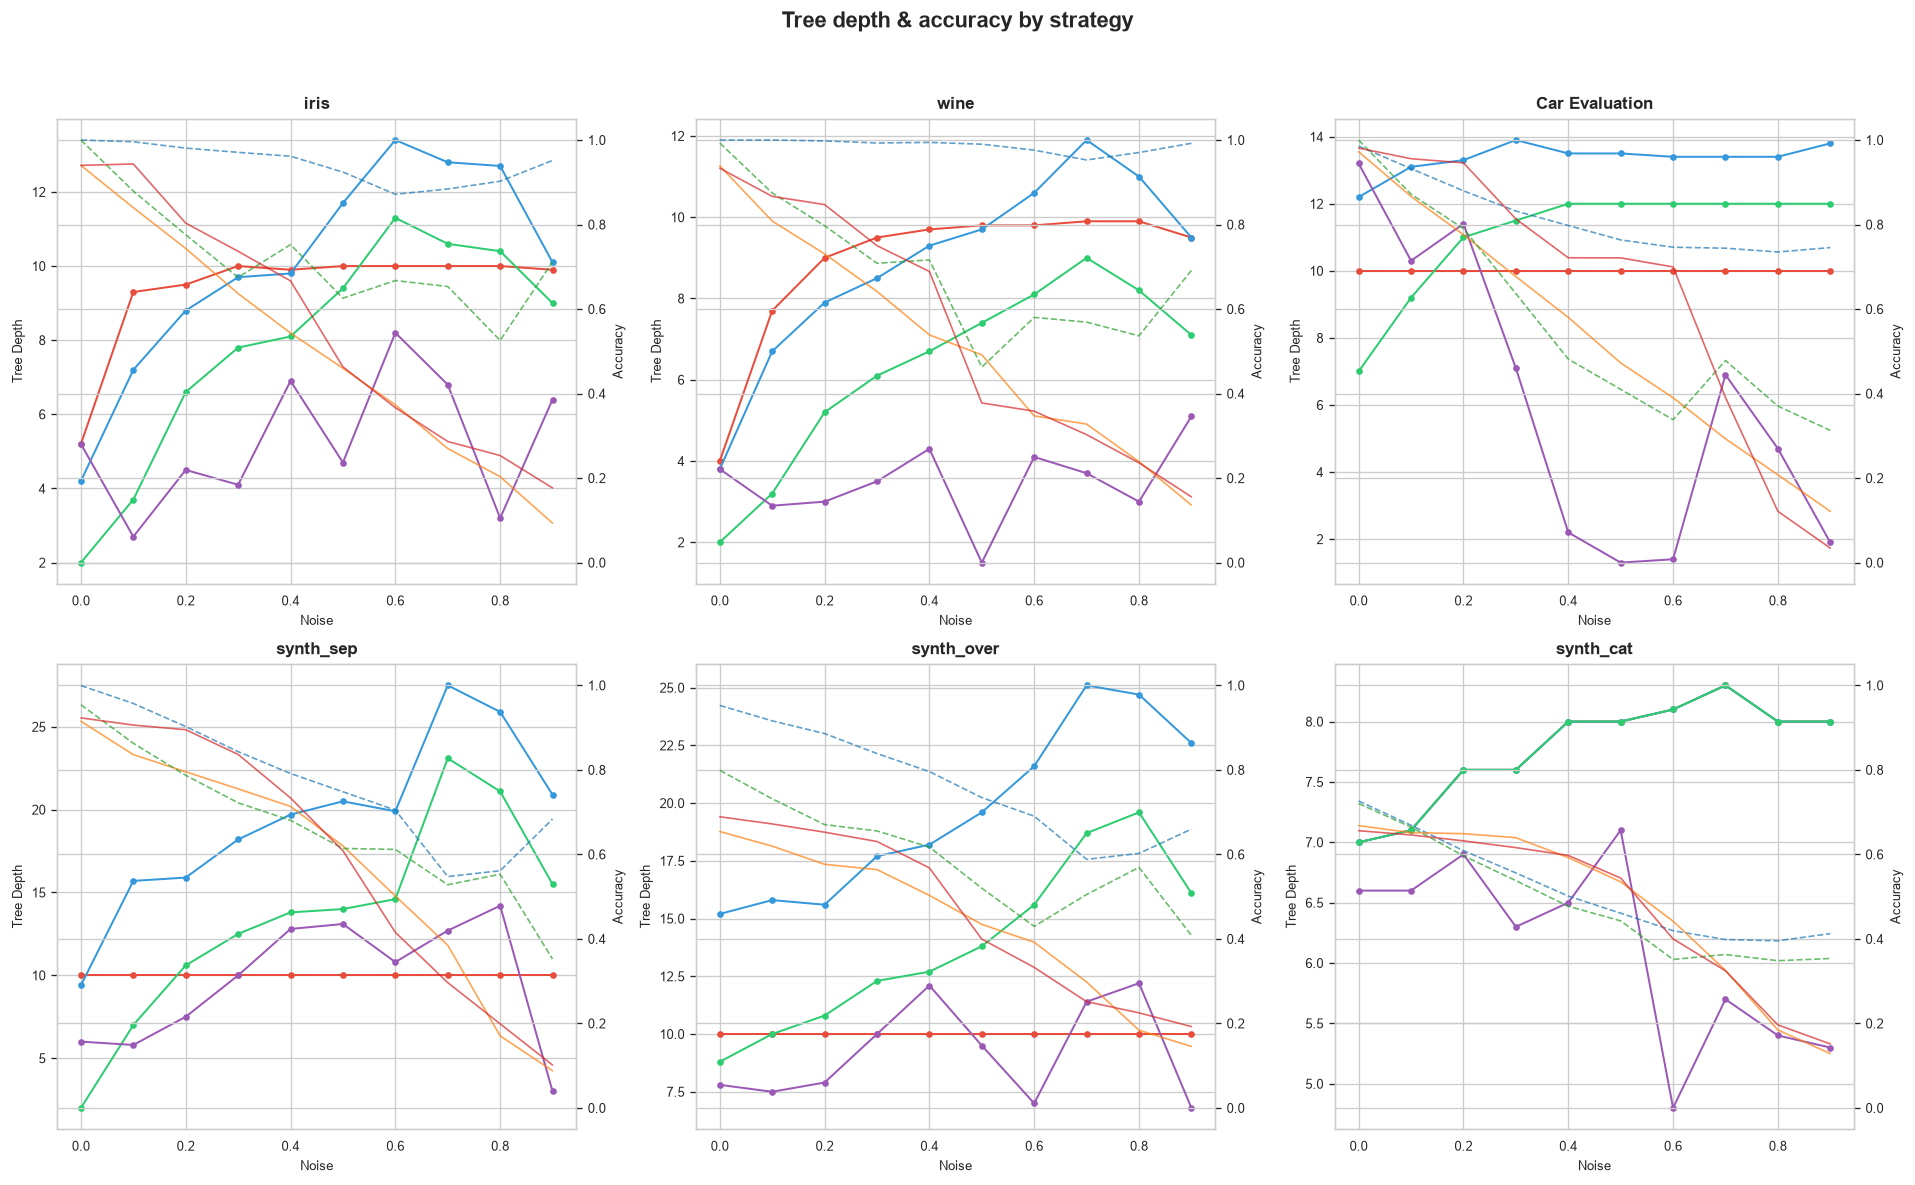

In [12]:
datasets_order = df.dataset.unique().tolist()
strategies = ["overfit", "unconstrained", "accuracy_90", "pruned"]
C = {"overfit": "#e74c3c", "unconstrained": "#3498db", "accuracy_90": "#2ecc71", "pruned": "#9b59b6"}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, ds_name in zip(axes.flat, datasets_order):
    sub = df[df.dataset == ds_name]
    for strat in strategies:
        ss = sub[sub.tree_strategy == strat]
        avg = ss.groupby("noise_level")[["tree_depth"]].mean()
        ax.plot(avg.index, avg["tree_depth"], "o-", ms=3, lw=1.2, color=C[strat])
    ax2 = ax.twinx()
    for strat in ["overfit", "pruned"]:
        ss = sub[sub.tree_strategy == strat]
        avg = ss.groupby("noise_level")[["train_acc", "test_acc"]].mean()
        ax2.plot(avg.index, avg["train_acc"], "--", lw=1, alpha=0.7)
        ax2.plot(avg.index, avg["test_acc"], "-", lw=1, alpha=0.7)
    ax.set_title(ds_name, fontweight="bold")
    ax.set_xlabel("Noise"); ax.set_ylabel("Tree Depth")
    ax2.set_ylabel("Accuracy"); ax2.set_ylim(-0.05, 1.05)
fig.suptitle("Tree depth & accuracy by strategy", fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0,0,1,0.95])
plt.show()


## 2. Density (z-scored) vs Noise - all strategies
Each row = dataset, columns = independent vs cumulative. Y-axis is z-score.

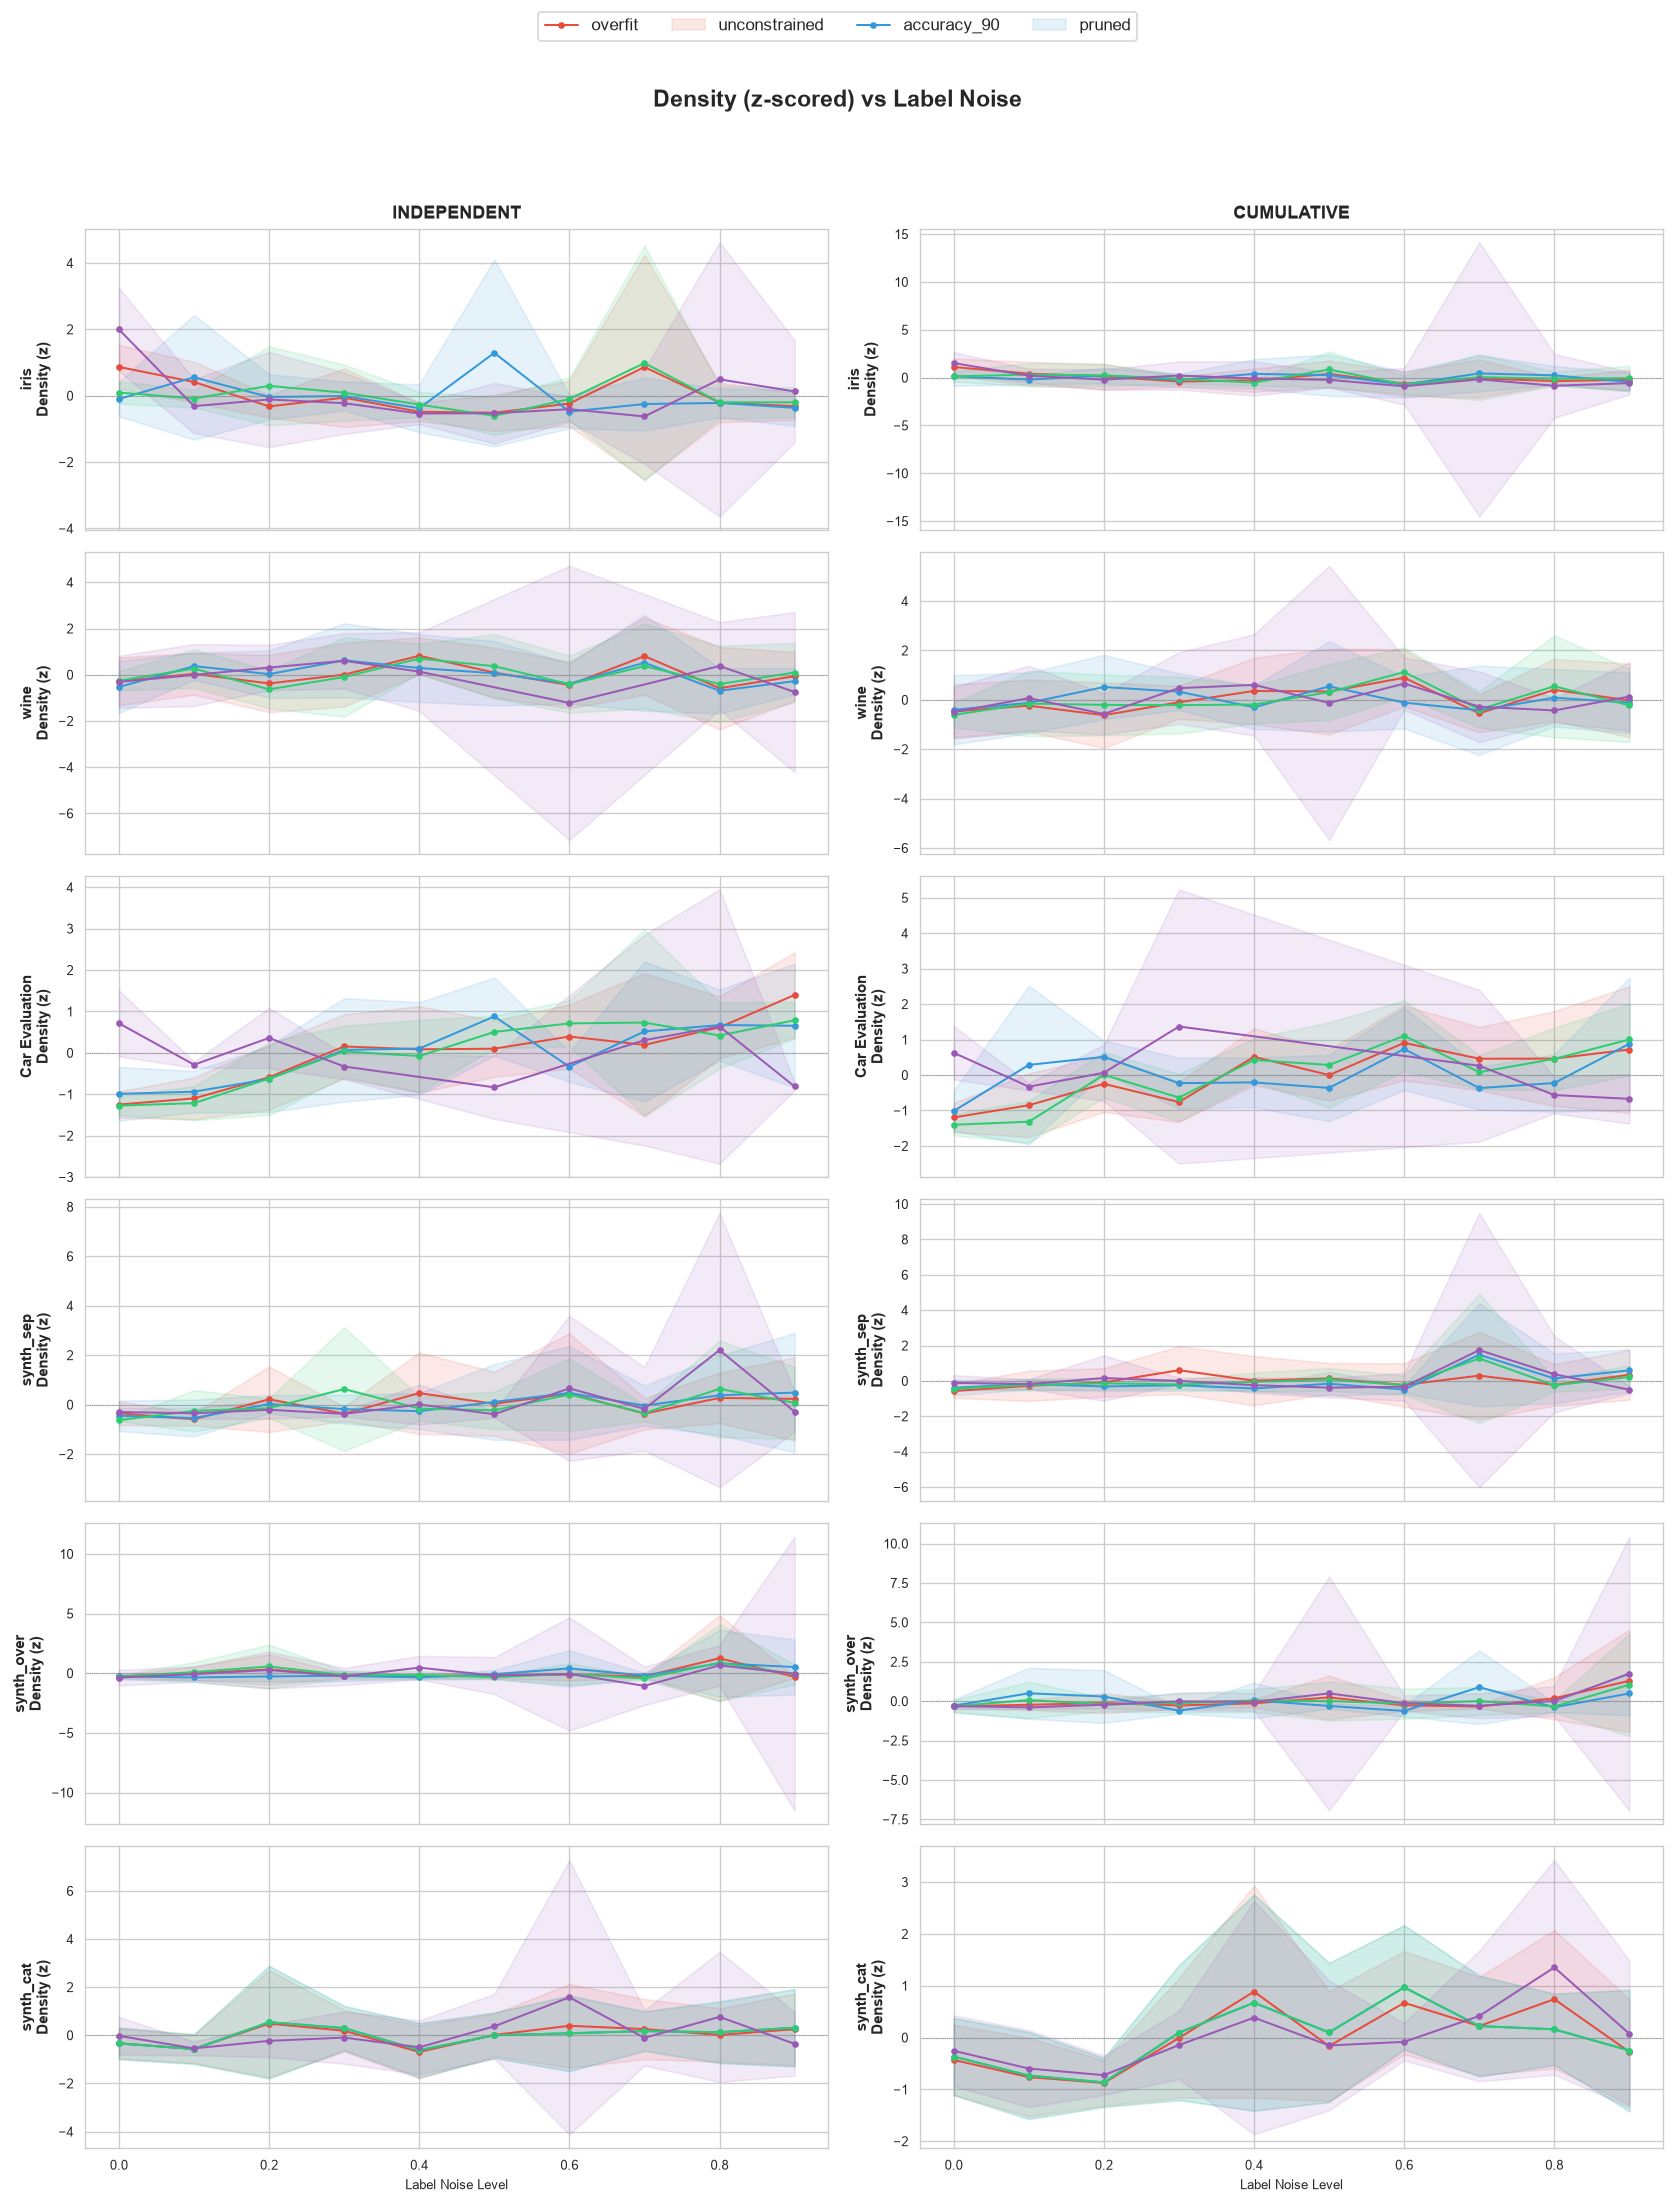

In [13]:
fig, axes = plt.subplots(len(datasets_order), 2, figsize=(14, 3*len(datasets_order)), sharex=True)

for row, ds_name in enumerate(datasets_order):
    sub = df[df.dataset == ds_name]
    for col, mode in enumerate(["independent", "cumulative"]):
        ax = axes[row, col]
        sm = sub[sub.noise_mode == mode]
        for strat in strategies:
            ss = sm[sm.tree_strategy == strat]
            agg = ss.groupby("noise_level")["density_z"].agg(["mean", "std", "count"])
            agg = agg[agg["count"] > 1]
            if len(agg) == 0: continue
            ci = stats.t.ppf(0.975, agg["count"]-1) * agg["std"] / np.sqrt(agg["count"])
            ax.plot(agg.index, agg["mean"], "-o", color=C[strat], ms=3, lw=1.2,
                    label=strat if (row==0 and col==0) else "")
            ax.fill_between(agg.index, agg["mean"]-ci, agg["mean"]+ci, color=C[strat], alpha=0.12)
        ax.axhline(y=0, color="gray", ls=":", lw=0.5)
        ax.set_ylabel(f"{ds_name}\nDensity (z)", fontsize=9, fontweight="bold")
        if row == 0: ax.set_title(f"{mode.upper()}", fontsize=11, fontweight="bold")
        if row == len(datasets_order)-1: ax.set_xlabel("Label Noise Level")

fig.legend(strategies, loc="upper center", ncol=4, fontsize=10, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Density (z-scored) vs Label Noise", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0,0,1,0.95])
plt.savefig(os.path.join(PLOT_DIR, "v2_density_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()


## 3. Independent vs Cumulative - direct overlay (overfit only)

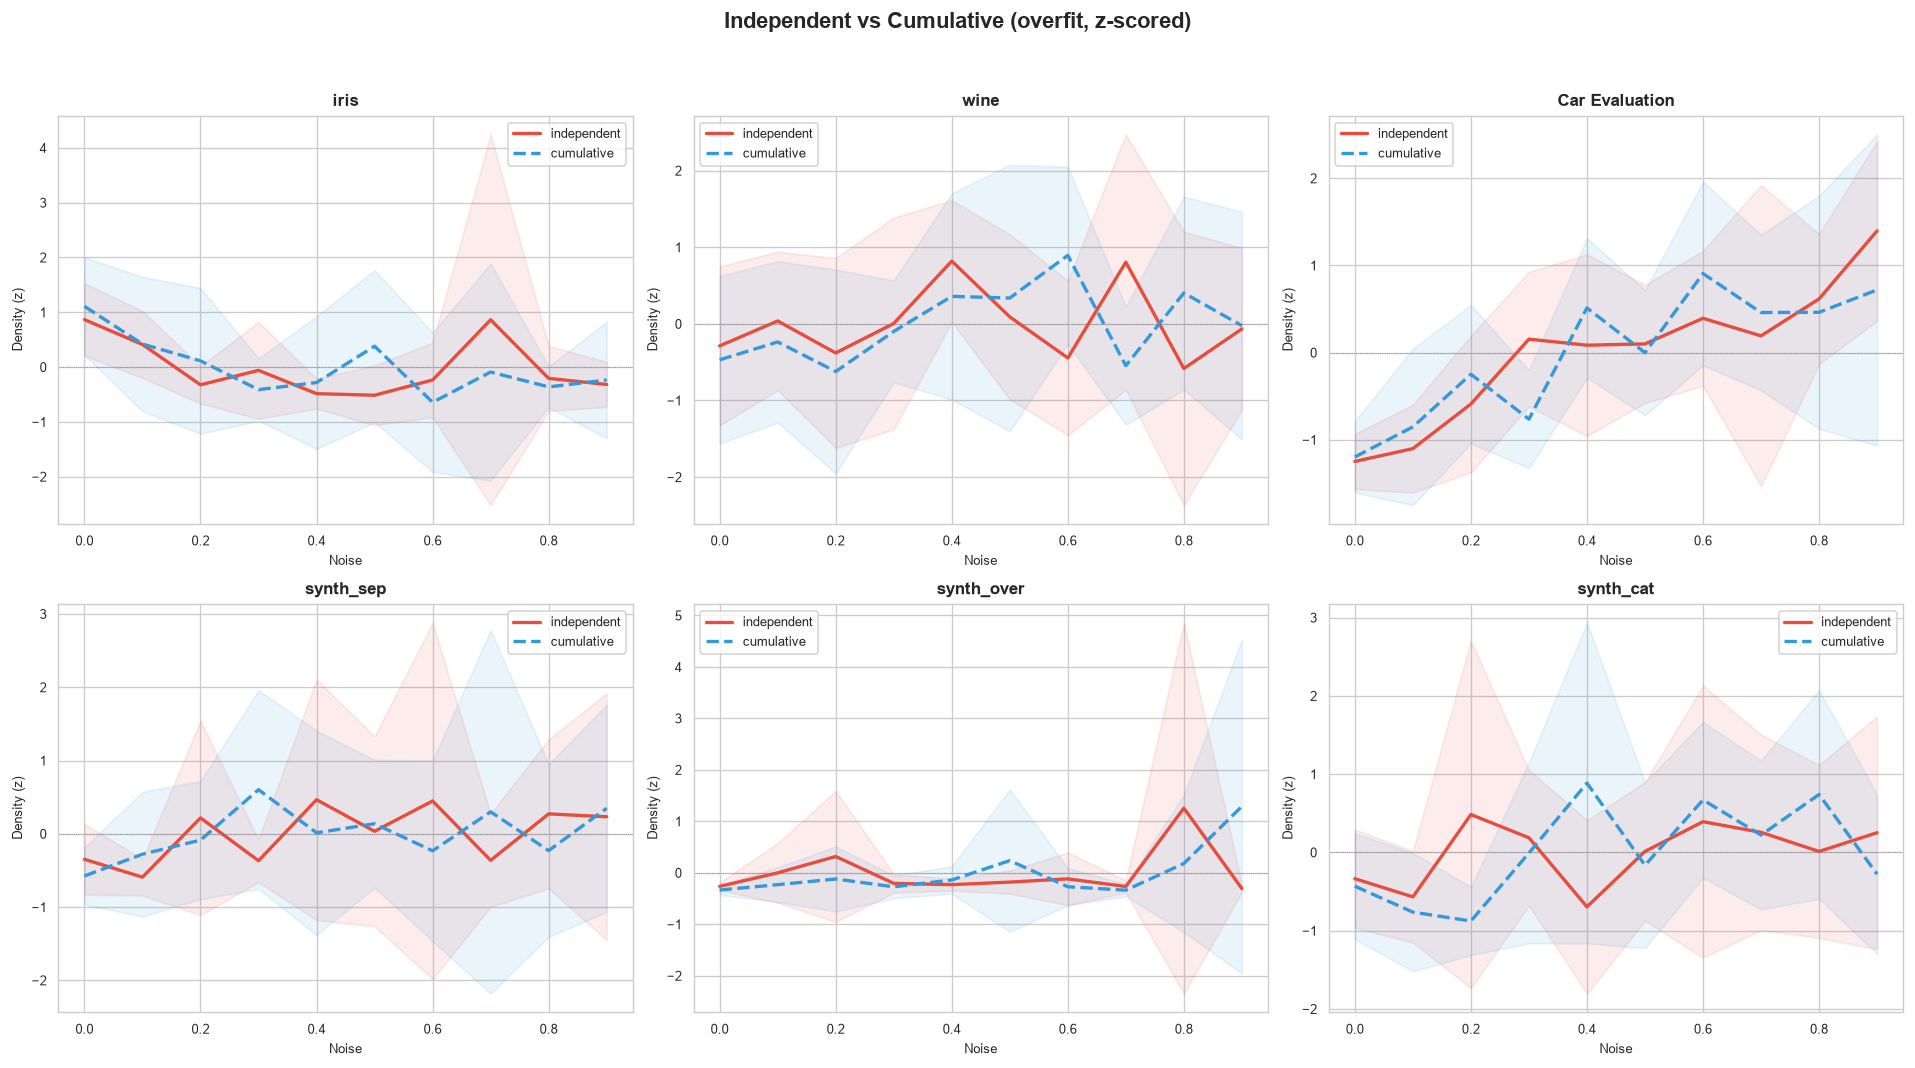

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, ds_name in zip(axes.flat, datasets_order):
    sub = df[(df.dataset == ds_name) & (df.tree_strategy == "overfit")]
    for mode, color, ls in [("independent", "#e74c3c", "-"), ("cumulative", "#3498db", "--")]:
        sm = sub[sub.noise_mode == mode]
        agg = sm.groupby("noise_level")["density_z"].agg(["mean", "std", "count"])
        ci = stats.t.ppf(0.975, agg["count"]-1) * agg["std"] / np.sqrt(agg["count"])
        ax.plot(agg.index, agg["mean"], color=color, ls=ls, lw=2, label=mode)
        ax.fill_between(agg.index, agg["mean"]-ci, agg["mean"]+ci, color=color, alpha=0.1)
    ax.axhline(y=0, color="gray", ls=":", lw=0.5)
    ax.set_title(ds_name, fontweight="bold")
    ax.set_xlabel("Noise"); ax.set_ylabel("Density (z)"); ax.legend()

fig.suptitle("Independent vs Cumulative (overfit, z-scored)", fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0,0,1,0.95])
plt.savefig(os.path.join(PLOT_DIR, "v2_mode_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()


## 4. Test accuracy vs noise

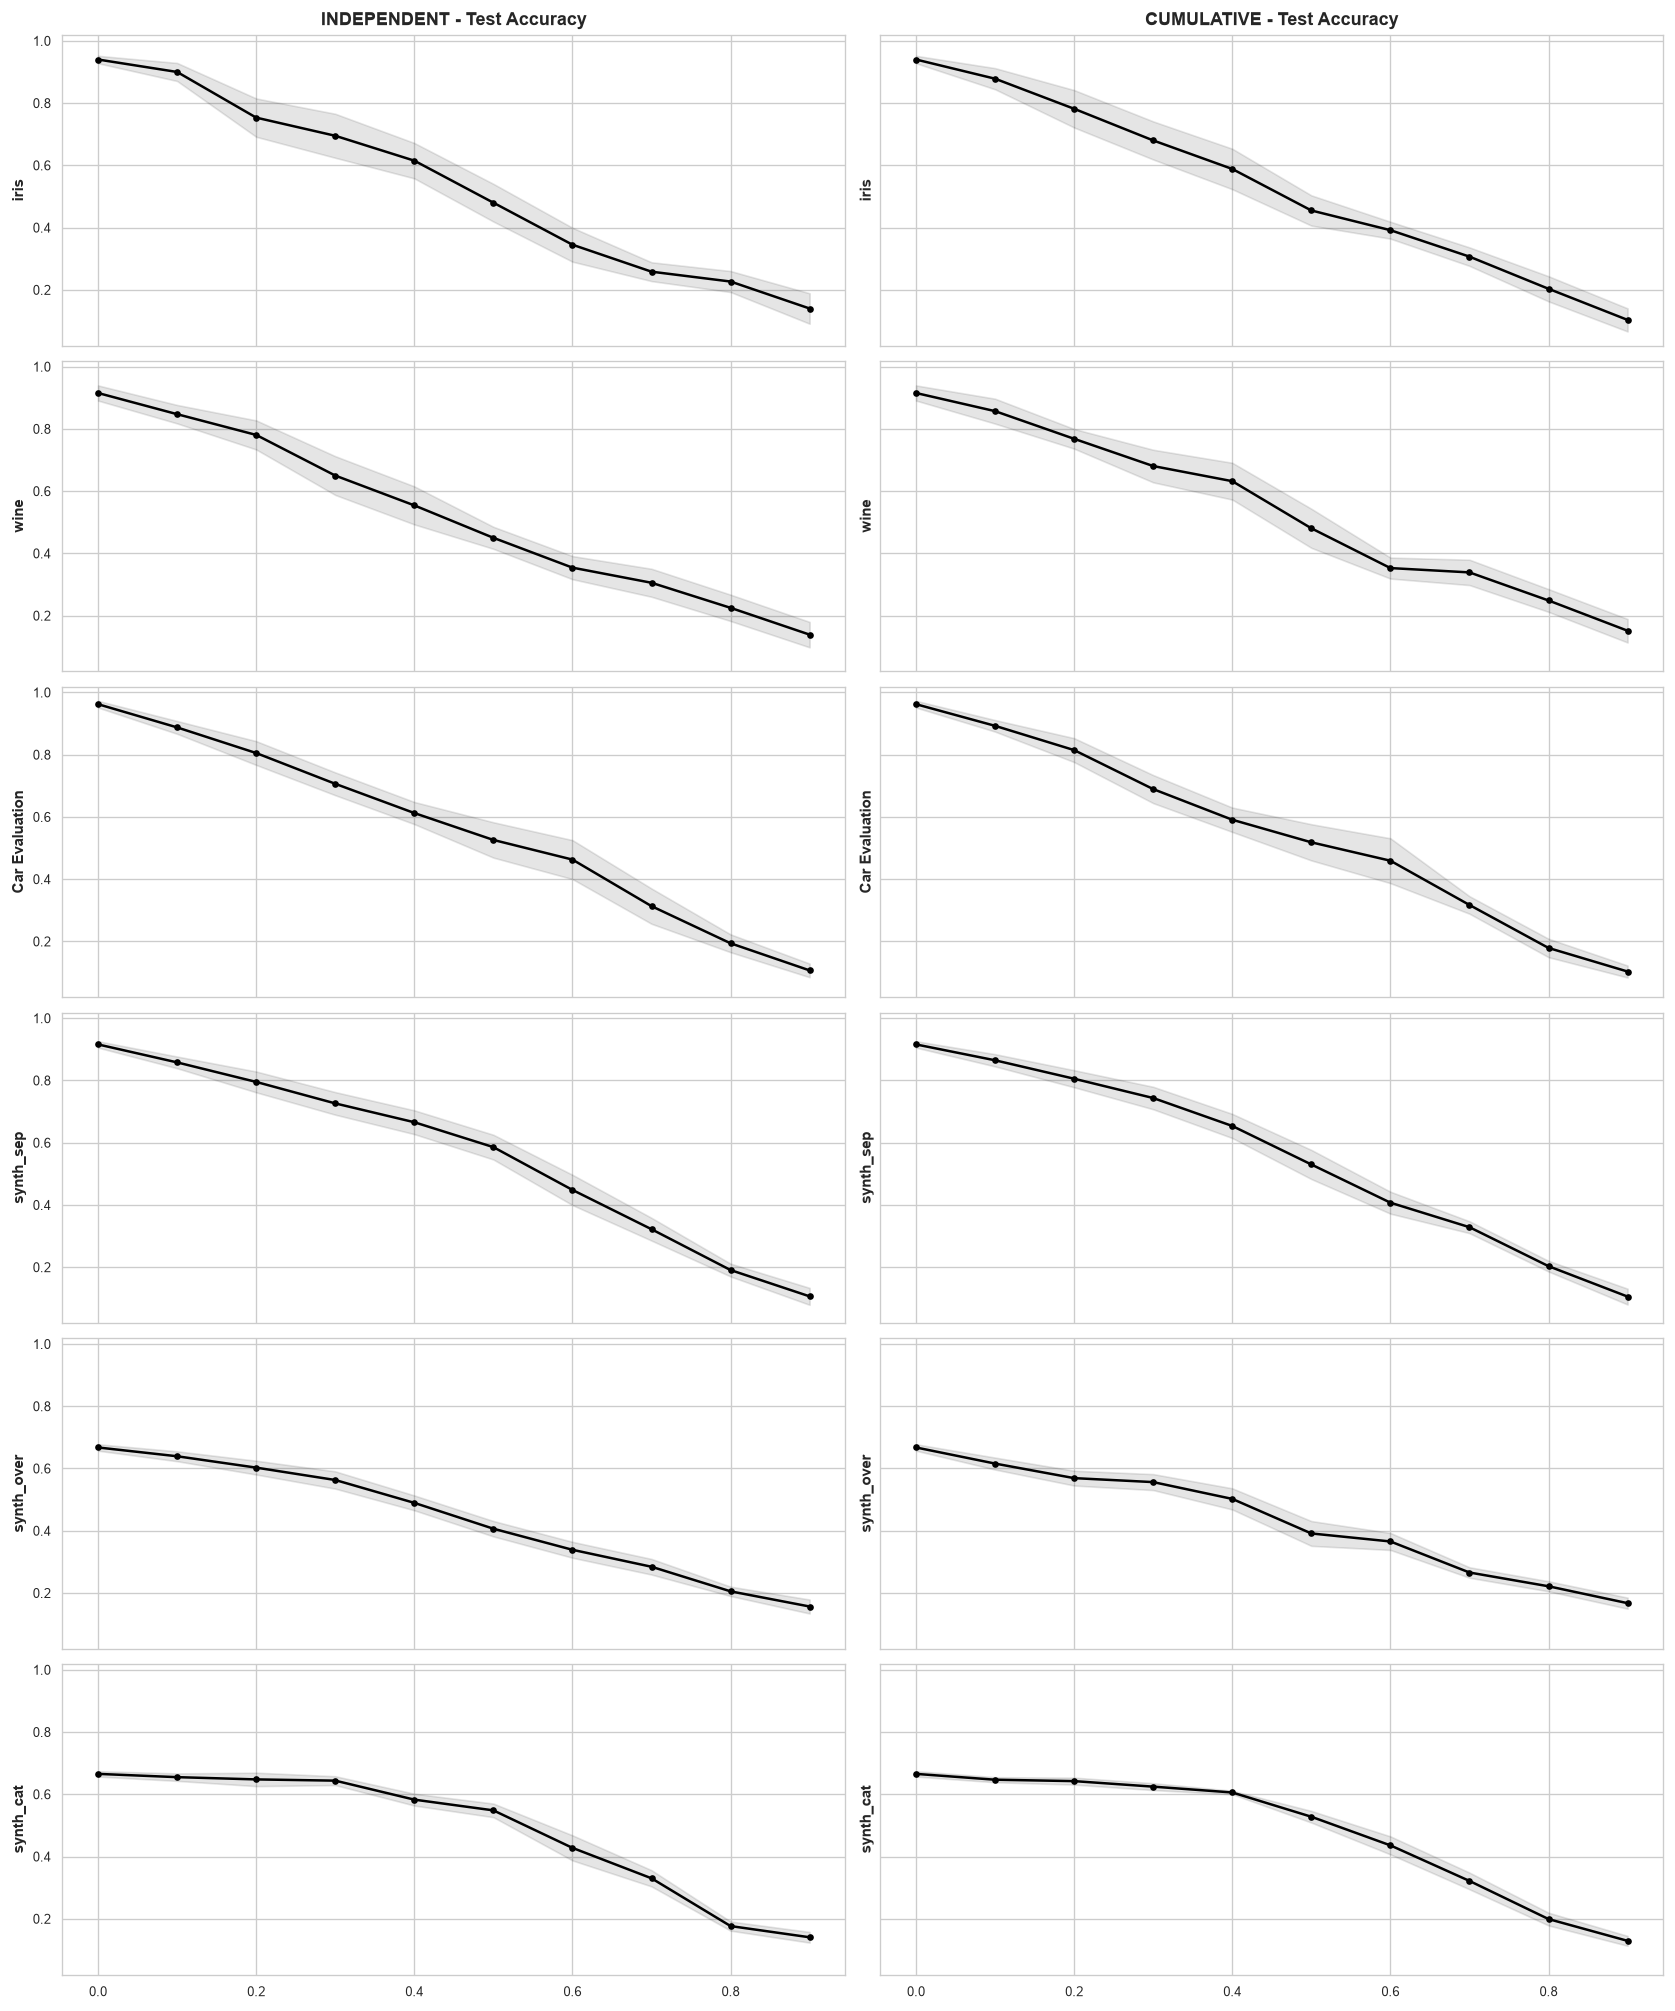

In [15]:
fig, axes = plt.subplots(len(datasets_order), 2, figsize=(14, 2.8*len(datasets_order)), sharex=True, sharey=True)

for row, ds_name in enumerate(datasets_order):
    sub = df[df.dataset == ds_name]
    for col, mode in enumerate(["independent", "cumulative"]):
        ax = axes[row, col]
        sm = sub[sub.noise_mode == mode]
        agg = sm.groupby("noise_level")["test_acc"].agg(["mean", "std", "count"])
        ci = stats.t.ppf(0.975, agg["count"]-1) * agg["std"] / np.sqrt(agg["count"])
        ax.plot(agg.index, agg["mean"], "ko-", ms=3, lw=1.5)
        ax.fill_between(agg.index, agg["mean"]-ci, agg["mean"]+ci, color="black", alpha=0.1)
        ax.set_ylabel(f"{ds_name}", fontsize=9, fontweight="bold")
        if row == 0: ax.set_title(f"{mode.upper()} - Test Accuracy", fontsize=11, fontweight="bold")

fig.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "v2_test_accuracy.png"), dpi=150, bbox_inches="tight")
plt.show()


## 5. Cluster count vs noise

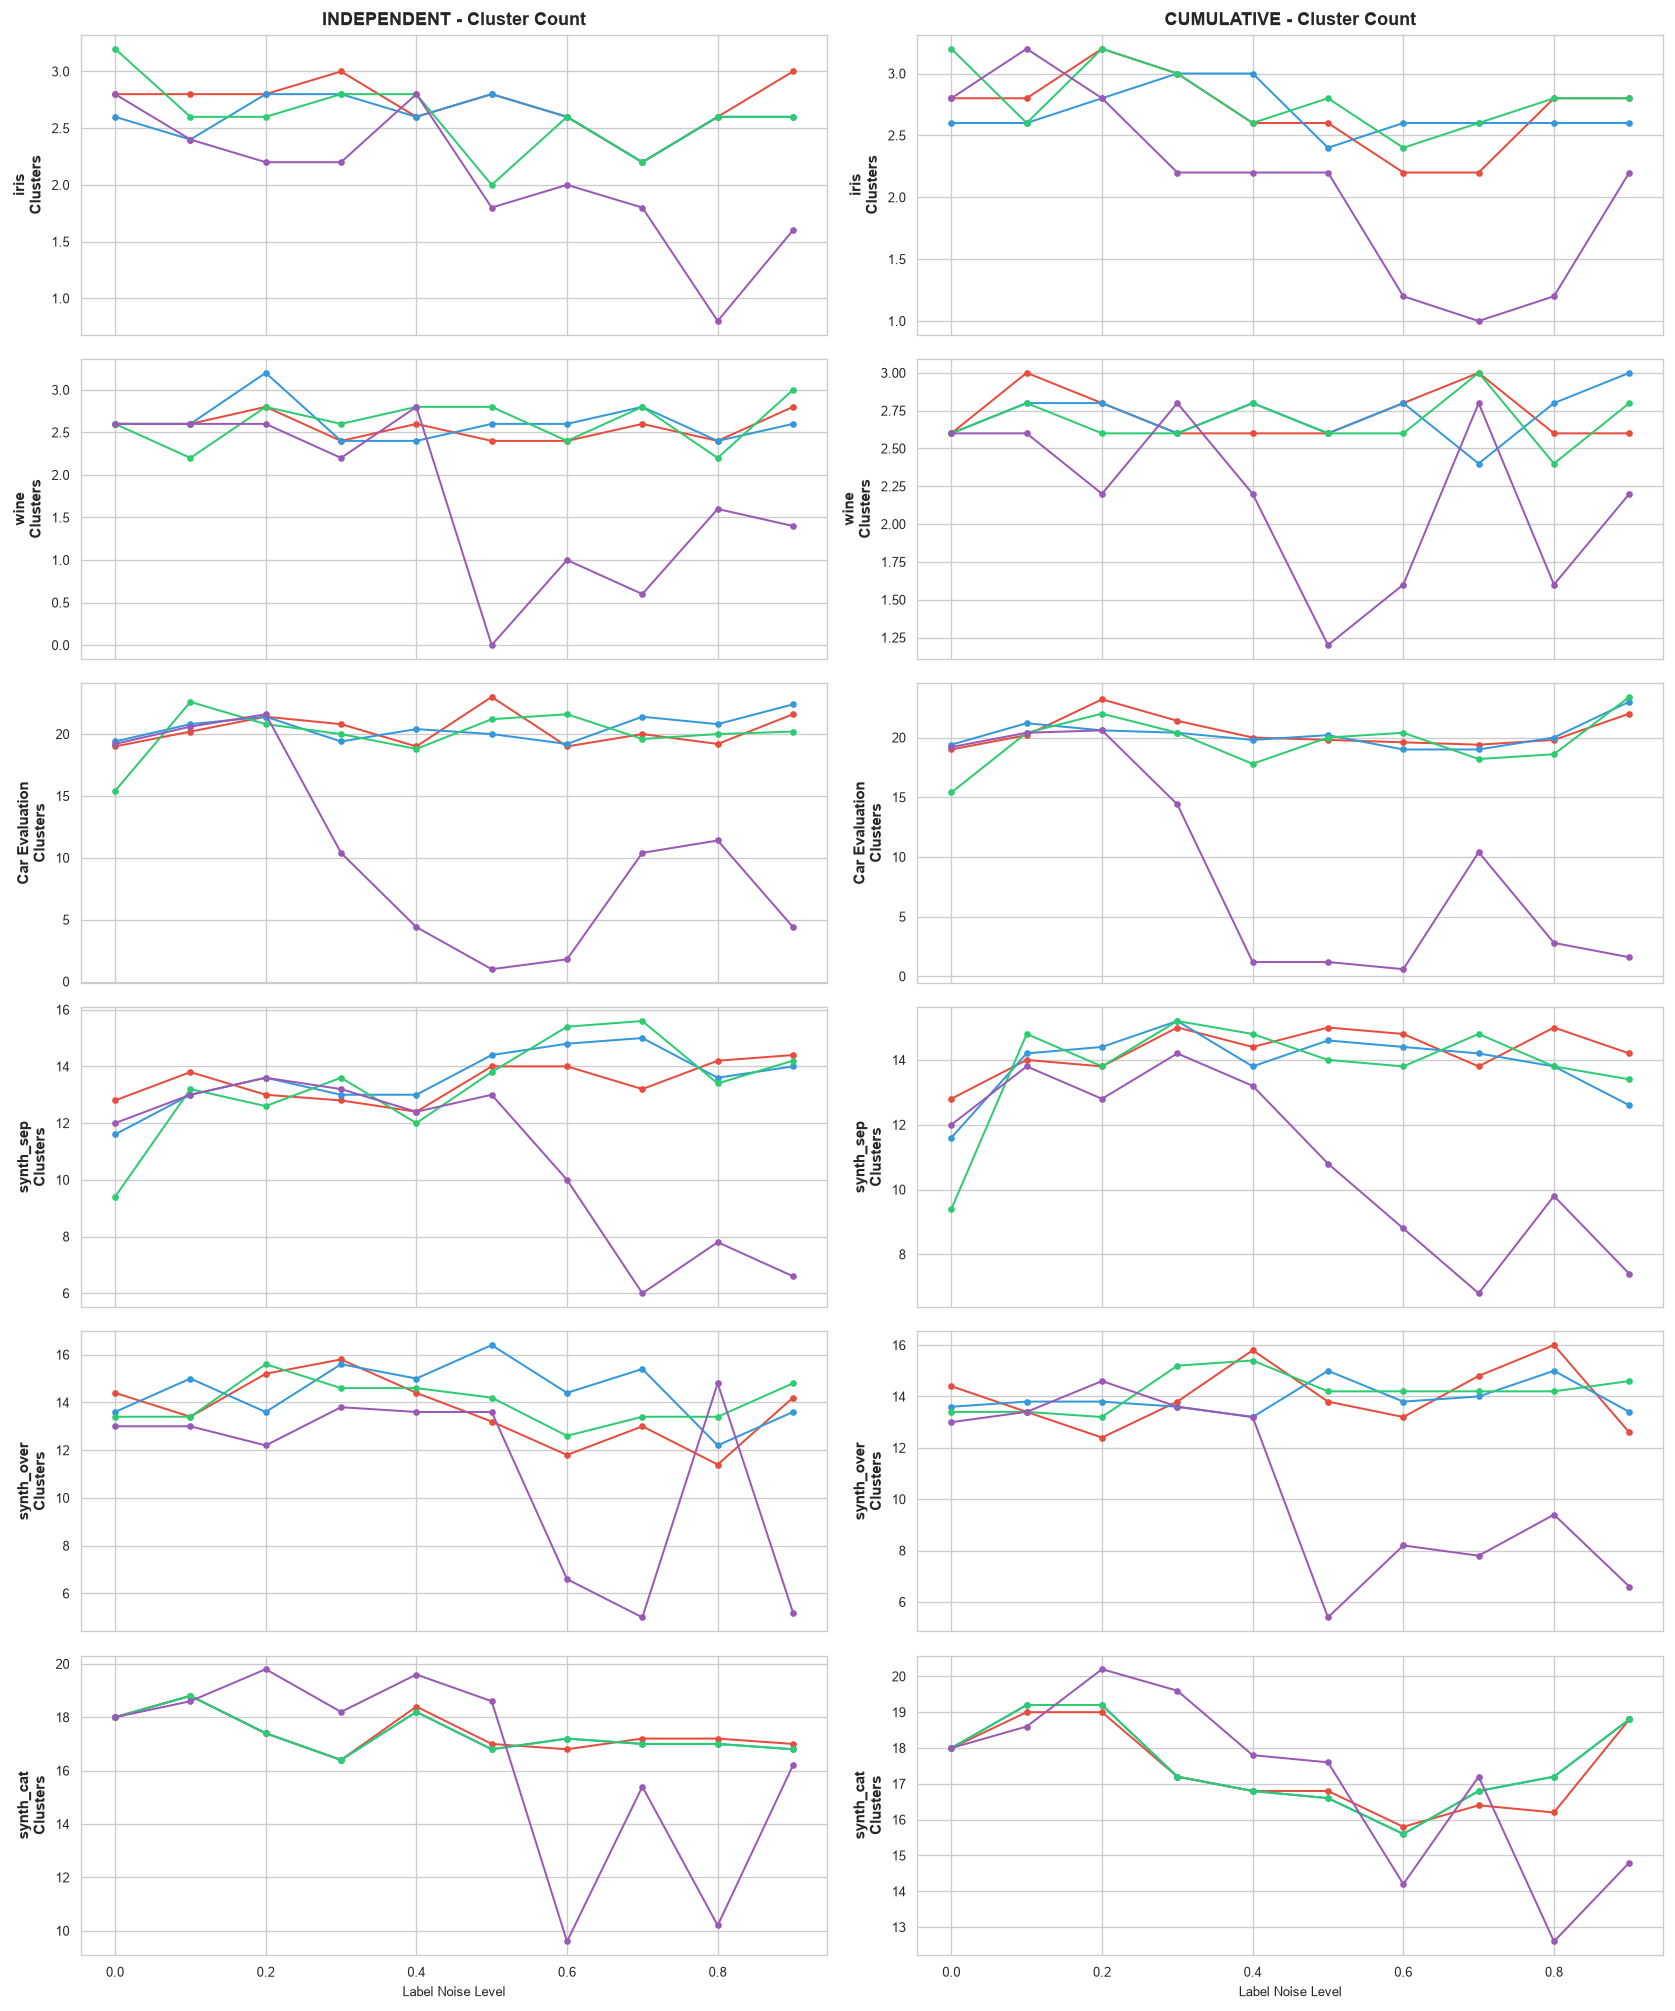

In [16]:
fig, axes = plt.subplots(len(datasets_order), 2, figsize=(14, 2.8*len(datasets_order)), sharex=True)

for row, ds_name in enumerate(datasets_order):
    sub = df[df.dataset == ds_name]
    for col, mode in enumerate(["independent", "cumulative"]):
        ax = axes[row, col]
        sm = sub[sub.noise_mode == mode]
        for strat in strategies:
            ss = sm[sm.tree_strategy == strat]
            agg = ss.groupby("noise_level")["n_clusters"].mean()
            ax.plot(agg.index, agg.values, "-o", color=C[strat], ms=3, lw=1.2)
        ax.set_ylabel(f"{ds_name}\nClusters", fontsize=9, fontweight="bold")
        if row == 0: ax.set_title(f"{mode.upper()} - Cluster Count", fontsize=11, fontweight="bold")
        if row == len(datasets_order)-1: ax.set_xlabel("Label Noise Level")

fig.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "v2_nclusters.png"), dpi=150, bbox_inches="tight")
plt.show()


## 6. Tree depth vs noise

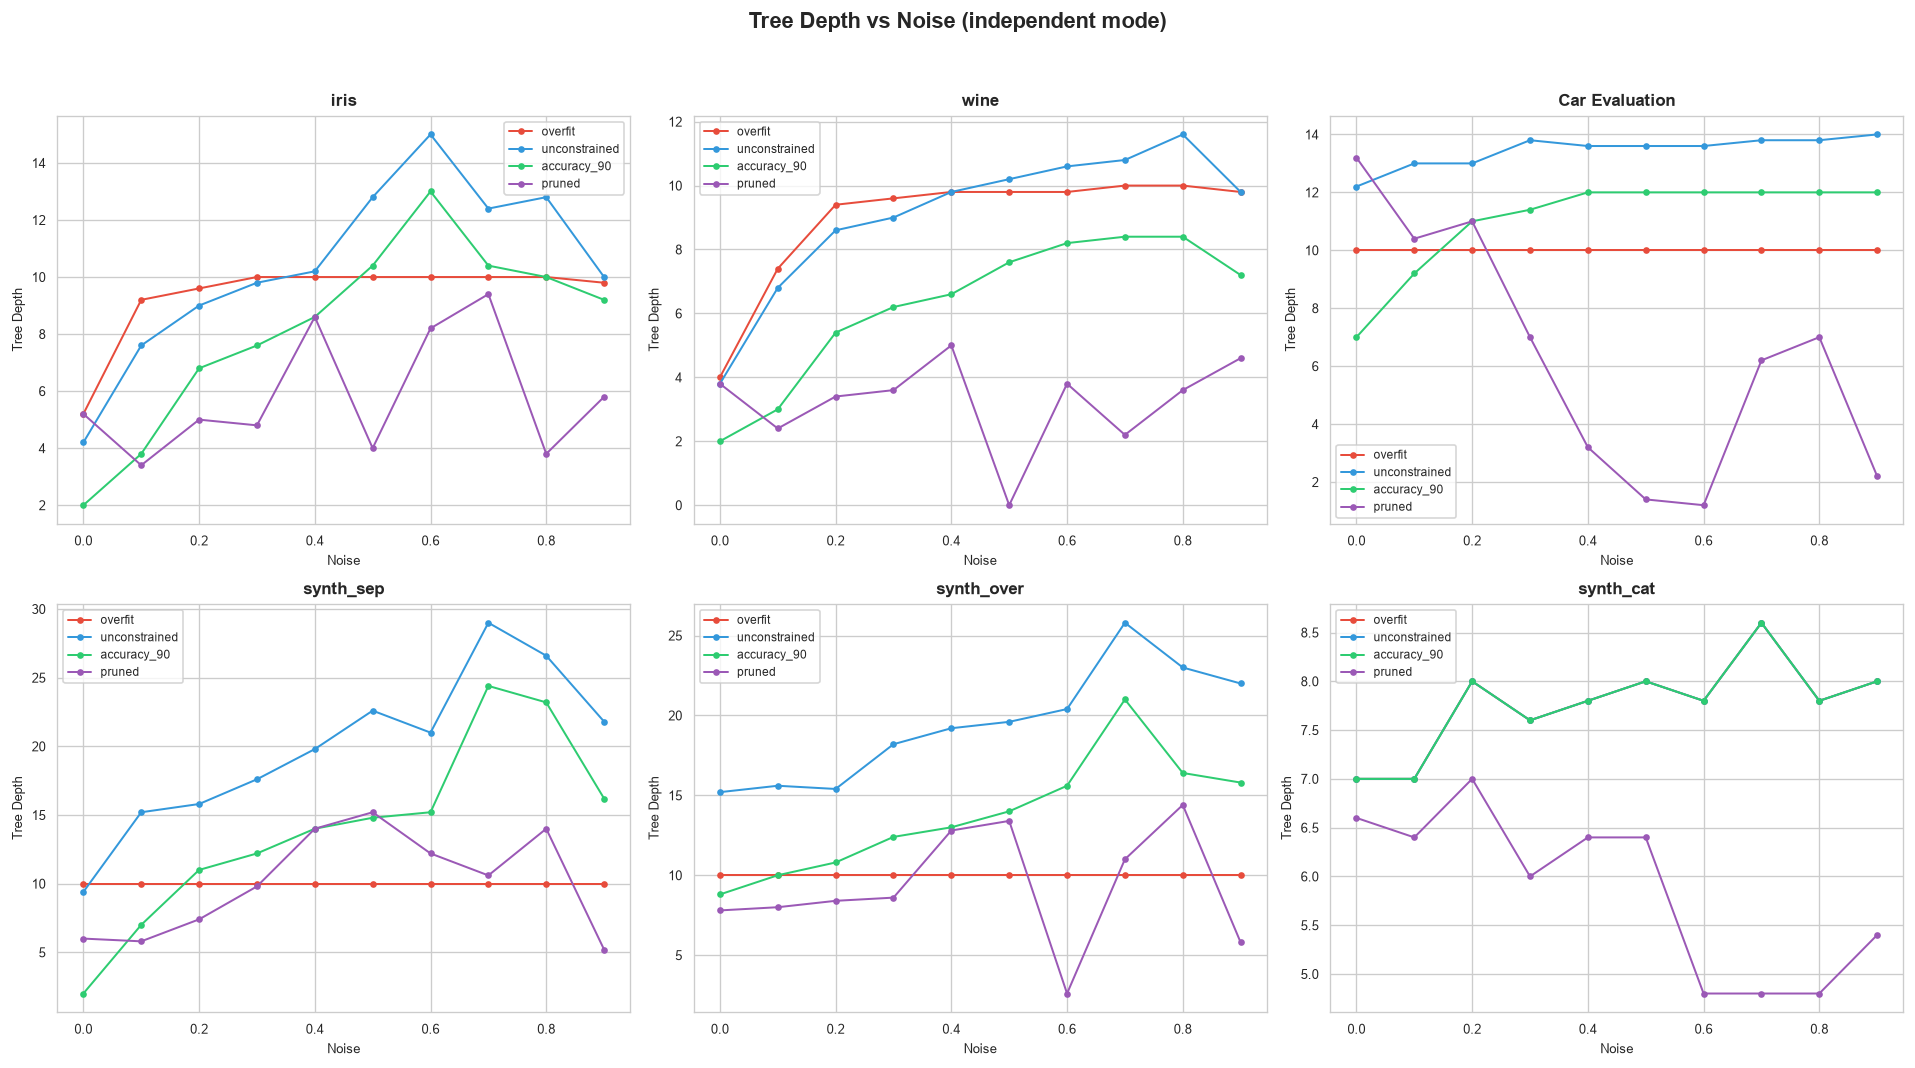

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, ds_name in zip(axes.flat, datasets_order):
    sub = df[df.dataset == ds_name]
    sm = sub[sub.noise_mode == "independent"]
    for strat in strategies:
        ss = sm[sm.tree_strategy == strat]
        agg = ss.groupby("noise_level")["tree_depth"].mean()
        ax.plot(agg.index, agg.values, "-o", color=C[strat], ms=3, lw=1.2, label=strat)
    ax.set_title(ds_name, fontweight="bold")
    ax.set_xlabel("Noise"); ax.set_ylabel("Tree Depth"); ax.legend(fontsize=7)

fig.suptitle("Tree Depth vs Noise (independent mode)", fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0,0,1,0.95])
plt.savefig(os.path.join(PLOT_DIR, "v2_tree_depth.png"), dpi=150, bbox_inches="tight")
plt.show()


## 7. KEY FINDING: Pruning kills the categorical spike
Car Evaluation: overfit vs pruned density (z-scored).

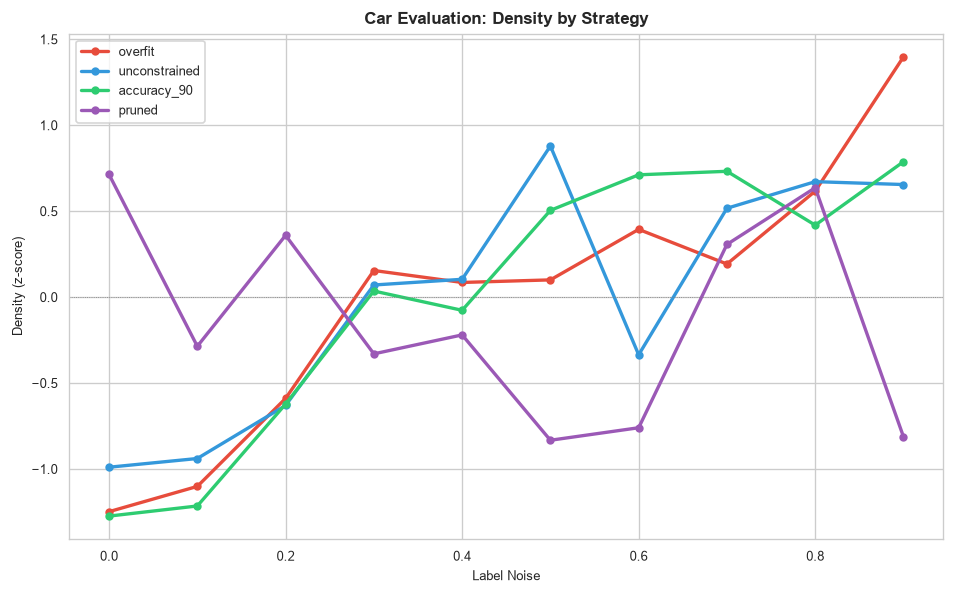

Density z trend (0.0 -> 0.9):
  overfit        : z=-1.25 -> z=+1.40
  unconstrained  : z=-0.99 -> z=+0.65
  accuracy_90    : z=-1.27 -> z=+0.79
  pruned         : z=+0.71 -> z=-0.81


In [18]:
sub = df[(df.dataset == "Car Evaluation") & (df.noise_mode == "independent")]
pivot = sub.pivot_table(values="density_z", index="noise_level", columns="tree_strategy", aggfunc="mean")

fig, ax = plt.subplots(figsize=(8, 5))
for strat in strategies:
    ax.plot(pivot.index, pivot[strat], "-o", color=C[strat], ms=4, lw=2, label=strat)
ax.axhline(y=0, color="gray", ls=":", lw=0.5)
ax.set_xlabel("Label Noise"); ax.set_ylabel("Density (z-score)")
ax.set_title("Car Evaluation: Density by Strategy", fontweight="bold"); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "v2_car_eval_detail.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Density z trend (0.0 -> 0.9):")
for s in strategies:
    vals = pivot[s].values
    print(f"  {s:15s}: z={vals[0]:+.2f} -> z={vals[9]:+.2f}")


## 8. Categorical datasets: raw density numbers

In [19]:
for ds_name in ["Car Evaluation", "synth_cat"]:
    sub = df[(df.dataset == ds_name) & (df.noise_mode == "independent")]
    pivot = sub.pivot_table(values="density", index="noise_level", columns="tree_strategy", aggfunc="mean")
    print(f"\n{ds_name} - raw density:")
    for s in strategies:
        vals = pivot[s].values
        trend = "UP" if vals[9] > vals[0] else "DOWN"
        print(f"  {s:15s}: {vals[0]:.2f} -> {vals[9]:.2f} ({vals[9]/vals[0]:.2f}x) {trend}")
    print(f"  Overfit at noise=0.5: {pivot['overfit'].iloc[5]:.2f}")
    print(f"  Pruned  at noise=0.5: {pivot['pruned'].iloc[5]:.2f}")



Car Evaluation - raw density:
  overfit        : 4.13 -> 19.28 (4.66x) UP
  unconstrained  : 3.89 -> 9.09 (2.34x) UP
  accuracy_90    : 4.25 -> 18.91 (4.45x) UP
  pruned         : 4.04 -> 0.52 (0.13x) DOWN
  Overfit at noise=0.5: 11.85
  Pruned  at noise=0.5: 0.47

synth_cat - raw density:
  overfit        : 49.94 -> 63.79 (1.28x) UP
  unconstrained  : 49.82 -> 64.29 (1.29x) UP
  accuracy_90    : 49.82 -> 64.29 (1.29x) UP
  pruned         : 45.00 -> 39.74 (0.88x) DOWN
  Overfit at noise=0.5: 58.17
  Pruned  at noise=0.5: 51.27
